# Chapter - 4.1 Coding an LLM architecture

##### we will specify the configuration of the small GPT-2 model via the following Python dictionary, which we will use in the code examples below

In [1]:
GPT_CONFIG_124M={
    "vocab_size":50257,
    "context_length":1024,
    "emb_dim":768,
    "n_heads":12,
    "n_layers":12,
    "drop_rate":0.1,
    "qkv_bias":False
}

######  implementing a GPT placeholder architecture (DummyGPTModel) for  big-picture view of how everything fits together and what other components we need to code in the upcoming sections to assemble the full GPT model architecture

### 4.1 A placeholder GPT model architecture class

In [2]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb= nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb=nn.Dropout(cfg["drop_rate"])
        self.trf_blocks=nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm= DummyLayerNorm(cfg["emb_dim"])
        self.out_head=nn.Linear(
            cfg["emb_dim"],cfg["vocab_size"],bias=False
        )
    def forward(self,in_idx):
        batch_size,seq_len= in_idx.shape
        token_emebds=self.tok_emb(in_idx)
        pos_embeds=self.pos_emb(torch.arange(seq_len,device=in_idx.device))
        x=token_emebds+ pos_embeds
        x=self.drop_emb(x)
        x=self.trf_blocks(x)
        x=self.final_norm(x)
        logits=self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()

    def forward(self,x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape,eps=1e-5):
        super().__init__()

    def forward(self,x):
        return x

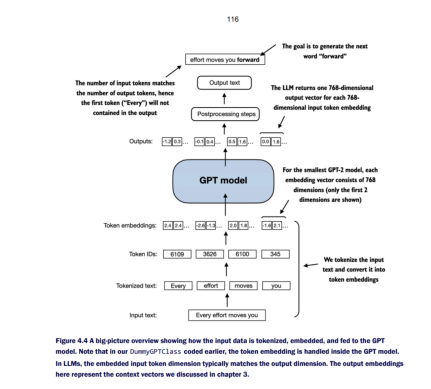

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.4.png")

plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
import torch
import tiktoken

In [5]:
tokenizer = tiktoken.get_encoding("gpt2")
batch=[]
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch=torch.stack(batch,dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


##### the first row corresponds to the first text, and the second row corresponds to the second text

##### Next, we initialize a new 124 million parameter DummyGPTModel instance and feed it the tokenized batch:


In [6]:
torch.manual_seed(123)
model=DummyGPTModel(GPT_CONFIG_124M)
logits=model(batch)
print("output shape:",logits.shape)
print(logits)

output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


In [7]:
logits[0]

tensor([[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
        [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
        [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
        [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],
       grad_fn=<SelectBackward0>)

In [8]:
logits[0].shape

torch.Size([4, 50257])

In [9]:
logits[0][0].shape

torch.Size([50257])

##### the output tensor has two rows corresponding to the two text samples. Each text sampleconsists of 4 tokens; each token is a 50,257-dimensional vector, which matches the size of the tokenizer's vocabulary.

##### the embedding has 50,257 dimensions because each of these dimensions refers to a unique token in the vocabulary. At the end of this chapter, when we implement the postprocessing code, we will convert these 50,257-dimensional vectors back into token IDs, which we can then decode into words.

##### Now that we have taken a top-down look at the GPT architecture and its in- and outputs, we will code the individual placeholders in the upcoming sections, starting with the real layer normalization class that will replace the DummyLayerNorm in the previous code.

### 4.2 Normalizing activations with layer normalization

##### deep neural networks are difficult to train because vanishing and exploding gradients make weight updates unstable, preventing the model from learning effectively.**

##### to solve that problem ,we will implement layer normalization to improve the stability and efficiency of neural network training.

##### the main idea behind layer normalization is to adjust the activations (outputs) of a neural network layer to have a mean of 0 and a variance of 1, also known as unit variance.

##### this adjustment speeds up the convergence to effective weights and ensures consistent,reliable training

##### layerNorm is applied before each Multi-Head Attention module, before each Feed-Forward Network, and once before the final output layer to stabilize activations and improve training.

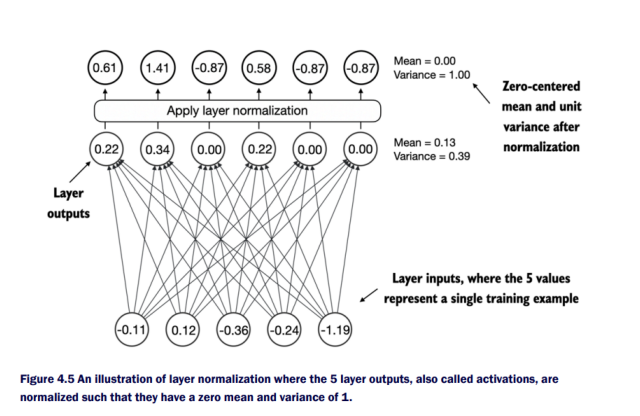

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.5.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### we can recreate the example shown in Figure 4.5 via the following code, where we implement a neural network layer with 5 inputs and 6 outputs that we apply to two input examples:

In [11]:
torch.manual_seed(123)
batch_example=torch.rand(2,5)  #batch size = 2; each sample is a 5-dimensional input vector
print(batch_example)

tensor([[0.2961, 0.5166, 0.2517, 0.6886, 0.0740],
        [0.8665, 0.1366, 0.1025, 0.1841, 0.7264]])


In [12]:
layer=nn.Sequential(nn.Linear(5,6),nn.ReLU())  #creates a neural network layer that transforms a 5D input into a 6D output using a Linear layer followed by ReLU.

In [13]:
layer

Sequential(
  (0): Linear(in_features=5, out_features=6, bias=True)
  (1): ReLU()
)

##### the neural network layer we have coded consists of a Linear layer followed by a non-linear activation function, ReLU (short for Rectified Linear Unit), which is a standard activation function in neural networks

In [14]:
out=layer(batch_example)
print(out)

tensor([[0.0000, 0.0000, 0.4091, 0.6587, 0.3914, 0.0000],
        [0.0000, 0.0000, 0.1902, 0.3182, 0.6486, 0.0000]],
       grad_fn=<ReluBackward0>)


##### as we can see, each output is of 6 dim

In [15]:
out[0].shape

torch.Size([6])

##### what we did now was create a neural network that takes a 5-dimensional input, transformed it into a 6-dimensional output using a linear layer, and then applied the ReLU activation function to produce the final 6-dimensional output.

#### basically till here, the highlighted section

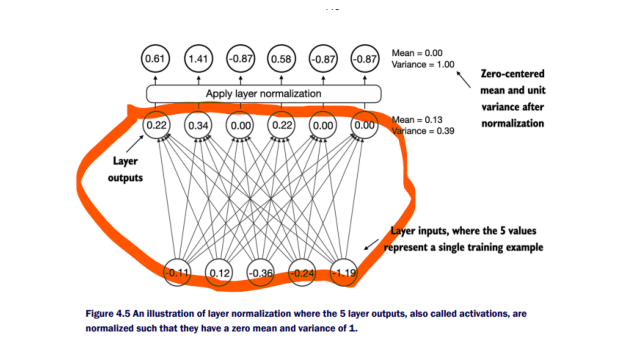

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.6.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### before we apply layer normalization to these outputs, let's examine the mean and variance:

In [17]:
mean=out.mean(dim=-1,keepdim=True)
var=out.var(dim=-1,keepdim=True)
print("mean:" ,mean)
print("variance:" ,var)

mean: tensor([[0.2432],
        [0.1928]], grad_fn=<MeanBackward1>)
variance: tensor([[0.0799],
        [0.0670]], grad_fn=<VarBackward0>)


#### so as we can see,
##### First training example (first row): Mean = 0.2432
##### Second training example (second row): Mean = 0.1928
##### First training example (first row): Variance = 0.0799
##### Second training example (second row): Variance = 0.0670

## Understanding `dim` when computing the mean (or variance)

Suppose we have the following tensor:

```python
out = torch.tensor([
    [0.22, 0.34, 0.00, 0.22, 0.00, 0.00],
    [0.21, 0.23, 0.00, 0.51, 0.32, 0.00]
])
```

The shape of this tensor is:

```text
(2, 6)
```

- **2 rows** → 2 training examples (batch size = 2)
- **6 columns** → 6 features (or activations) for each example

---

## Case 1: `dim=1` (or `dim=-1`)

```python
mean = out.mean(dim=1)
```

This computes the mean **across the columns**, meaning each row is averaged independently.

### Input 1

```text
0.22  0.34  0.00  0.22  0.00  0.00
 └────────────── Average these ──────────────┘
```

Mean = **0.13**

### Input 2

```text
0.21  0.23  0.00  0.51  0.32  0.00
 └────────────── Average these ──────────────┘
```

Mean = **0.21**

Result:

```python
tensor([0.13, 0.21])
```

Each training example gets **its own mean**.

This is exactly what **Layer Normalization** needs.

---

## Case 2: `dim=0`

```python
mean = out.mean(dim=0)
```

This computes the mean **down the rows**, meaning each column is averaged independently.

### Column 1

```text
0.22
0.21
────
Mean = 0.21
```

### Column 2

```text
0.34
0.23
────
Mean = 0.29
```

### Column 3

```text
0.00
0.00
────
Mean = 0.00
```

...

Result:

```python
tensor([0.21, 0.29, 0.00, 0.37, 0.16, 0.00])
```

Here, each **feature (column)** gets its own mean.

---

## Why does LayerNorm use `dim=-1`?

Suppose our tensor has shape:

```python
out.shape
```

```text
torch.Size([2, 6])
```

Each row represents one training example.

LayerNorm should normalize **each training example independently**, so it computes:

```python
mean = out.mean(dim=-1, keepdim=True)
```

This produces:

```text
Input 1 → Mean = 0.13
Input 2 → Mean = 0.21
```

These means are then used to normalize each row separately.

---

## Why `dim=-1` instead of `dim=1`?

For a **2D tensor**, `dim=1` and `dim=-1` are identical because the last dimension is dimension 1.

However, GPT does not work with 2D tensors. It uses tensors with shape:

```text
(batch_size, sequence_length, embedding_dimension)
```

For example:

```text
(2, 4, 768)
```

where:

- `dim=0` → Batch dimension
- `dim=1` → Sequence (tokens)
- `dim=2` → Embedding dimension

or equivalently:

- `dim=-1` → Embedding dimension (the last dimension)

LayerNorm should normalize **each token's embedding vector**, so it always computes the mean and variance along the **last dimension**.

Using `dim=-1` makes the code work correctly for both 2D tensors and higher-dimensional tensors.

---

## Summary

- **`dim=0`** → Compute the mean (or variance) **down each column** (one value per feature).
- **`dim=1`** → Compute the mean (or variance) **across each row** (one value per training example).
- **`dim=-1`** → Compute the mean (or variance) along the **last dimension**. For a 2D tensor, this is the same as `dim=1`. For GPT's 3D tensors, it means normalizing each token's embedding vector independently.

##### now ,apply layer normalization to the layer outputs we obtained earlier. The operation consists of subtracting the mean and dividing by the square root of the variance (also known as standard deviation):

In [18]:
out_norm=(out-mean)/ torch.sqrt(var)

In [19]:
print(out_norm)

tensor([[-0.8603, -0.8603,  0.5869,  1.4698,  0.5242, -0.8603],
        [-0.7450, -0.7450, -0.0102,  0.4844,  1.7608, -0.7450]],
       grad_fn=<DivBackward0>)


#### the values are now normalized, now lets recheck the men and varince.

In [20]:
mean=out_norm.mean(dim=-1,keepdim=True)
var=out_norm.var(dim=-1,keepdim=True)
print("mean:" ,mean)
print("variance:" ,var)

mean: tensor([[-3.9736e-08],
        [-1.9868e-08]], grad_fn=<MeanBackward1>)
variance: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


##### note that, the mean values [-3.9736e-08] and  [-1.9868e-08] are values very close to zero,To improve readability, we can also turn off the scientific notation when printing tensorvalues by setting sci_mode to False:

In [21]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


##### now we can see that, after applying the normalization our means and variance are 0 and 1 respectively

##### we have coded and applied layer normalization in a step-by-step process. Let's now encapsulate this process in a PyTorch module that we can use in the GPT model later:

In [22]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5 #keeps the denominator non-zero and makes the computation numerically stable.
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

##### Without scale and shift, every layer would always output values with mean 0 and variance 1. That normalization is useful for stable training, but it's also restrictive. The learnable scale and shift let the model keep the training benefits of normalization while still learning whatever output distribution is most useful for the task

##### the final output of LayerNorm is: output=scale×normalized_value+shift

##### **BIASED VARIANCE**

###### In our variance calculation method, we have opted for an implementation detail by setting `unbiased=False`. For those curious about what this means, in the variance calculation, we divide by the number of inputs `n` in the variance formula. This approach does not apply Bessel's correction, which typically uses `n−1` instead of `n` in the denominator to adjust for bias in sample variance estimation. This decision results in a so-called biased estimate of the variance. For large-scale language models (LLMs), where the embedding dimension `n` is significantly large, the difference between using `n` and `n−1` is practically negligible. We chose this approach to ensure compatibility with the GPT-2 model's normalization layers and because it reflects TensorFlow's default behavior, which was used to implement the original GPT-2 model. Using a similar setting ensures our method is compatible with the pretrained weights we will load in chapter 6.


##### now try the LayerNorm module in practice and apply it to the batch input:

In [23]:
ln=LayerNorm(emb_dim=5) #instantiate the normlayer

out_ln=ln(batch_example) 
mean=out_ln.mean(dim=-1,keepdim=True)
var=out_ln.var(dim=-1,unbiased=False, keepdim=True)
print("mean: ",mean)
print("var:", var)

mean:  tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
var: tensor([[0.9998],
        [0.9999]], grad_fn=<VarBackward0>)


##### In this section, we covered one of the building blocks we will need to implement the GPT architecture, as shown in the mental model in Figure 4.7.

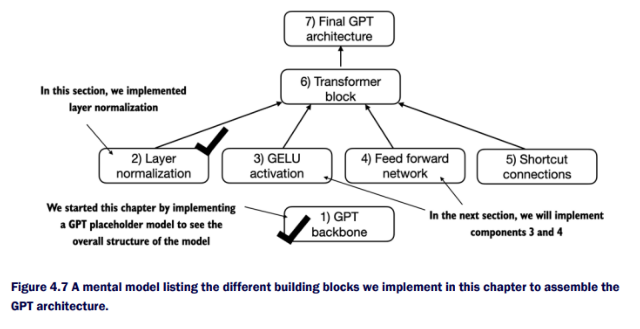

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.7.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### In the next section, we will look at the GELU activation function, which is one of theactivation functions used in LLMs, instead of the traditional ReLU function we used in this section.


##### lAYER NORMALIZATION VERSUS BATCH NORMALIZATION

#####  Unlike batch normalization, which normalizes across the batch dimension, layer normalization normalizes across the feature dimension. LLMs often require significant computational resources, and the available hardware or the specific use case can dictate the batch size during training or inference. Since layer normalization normalizes each input independently of the batch size, it offers more flexibility and stability in these scenarios. This is particularly beneficial for distributed training or when deploying models in environments where resources are constrained

### 4.3 Implementing a feed forward network with GELU activations

##### we will implement a small neural network submodule that is used as part of thetransformer block in LLMs. We begin with implementing the GELU activation function, whichplays a crucial role in this neural network submodule

##### Activation Functions in Modern LLMs

Historically, **ReLU (Rectified Linear Unit)** was the most commonly used activation function because it is simple, computationally efficient, and effective. Modern LLMs, however, typically use more advanced activation functions like **GELU (Gaussian Error Linear Unit)** and **SwiGLU (Swish-Gated Linear Unit)**, which are smoother and generally achieve better performance in deep neural networks.

The **GELU** activation function is mathematically defined as:

$$
\text{GELU}(x) = x \cdot \Phi(x)
$$

where $\Phi(x)$ is the **cumulative distribution function (CDF)** of the standard Gaussian (normal) distribution.

> **Note:** In practice, models such as **GPT-2** use a computationally cheaper approximation of GELU instead of the exact formula, as it provides nearly identical performance while being faster to compute.

##### In practice, however, it's common to implement a computationally cheaper approximation (the original GPT-2 model was also trained with this approximation)

The computationally efficient approximation of the **GELU** activation function used in GPT-2 is:

$$
\operatorname{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \cdot \left(x + 0.044715 \cdot x^3\right)\right]\right)
$$

##### implementation of the above func in pytorch

In [25]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5* x + (1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+ 0.044715*torch.pow(x,3))))

##### to get an idea of what this GELU function looks like and how it compares to the ReLUfunction, let's plot these functions side by side:

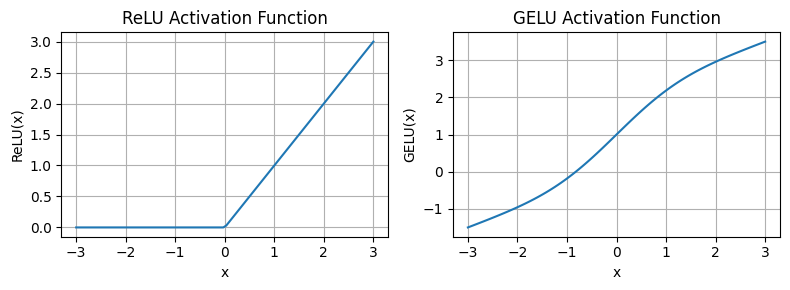

In [26]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))

# ReLU on the left, GELU on the right
for i, (y, label) in enumerate(zip([y_relu, y_gelu], ["ReLU", "GELU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} Activation Function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

##### ReLU vs. GELU

- **ReLU (Rectified Linear Unit)** is a **piecewise linear** activation function:
  - For negative inputs: outputs **0**.
  - For positive inputs: outputs the input unchanged.
  - Formula:
    $$
    \text{ReLU}(x)=\max(0,x)
    $$

- **GELU (Gaussian Error Linear Unit)** is a **smooth, nonlinear** activation function:
  - Behaves similarly to ReLU but transitions smoothly instead of having a sharp corner at \(x=0\).
  - Large positive inputs pass through almost unchanged.
  - Large negative inputs are suppressed but **not abruptly set to zero**.

- **Key Difference:**
  - **ReLU** has a **zero gradient** for all negative inputs because its output is flat (always 0) on the negative side.
  - **GELU** has a **non-zero gradient** for negative inputs because its curve is smooth. This allows gradients to continue flowing during backpropagation, helping the model learn more effectively.

- Because of its smoother behavior and better gradient flow, **modern LLMs (e.g., GPT-2)** use **GELU** instead of ReLU.

##### use the GELU function to implement the small neural network module, FeedForward, that we will be using in the LLM's transformer block later

In [27]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers= nn.Sequential(
            nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]), # we had emb_dim=768, so first layer will be of (768,3072)
            GELU(), #apply gelu activation
            nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]), # output will be of (3072*768)
        )

    def forward(self,x):
        return self.layers(x)

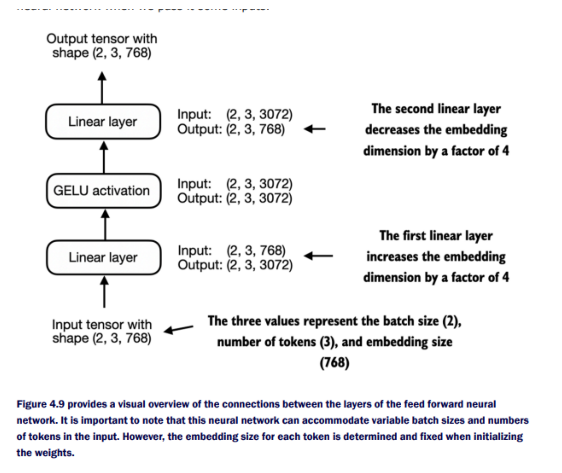

In [28]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.9.png")

plt.figure(figsize=(7, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### the visualization of the above network looks something like this

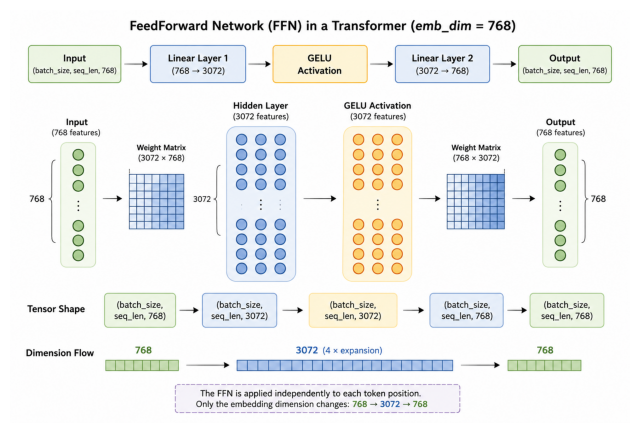

In [29]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("feedforward.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### whats happening in the above FeedForward Network (FFN) is that :

1. Receive a **768-dimensional embedding** for each token.
2. **Expand** the embedding using a linear layer (**768 → 3072**) to create a richer feature representation.
3. Apply **GELU** to introduce **non-linearity** while keeping the dimension the same (**3072**).
4. **Project** the representation back to the original embedding size using another linear layer (**3072 → 768**).
5. Pass the transformed **768-dimensional embedding** to the next Transformer block.

#### initialize the FeedForward module with a token embedding size of 768 and feed it a batch input with 2 samples and 3 tokens each:

In [30]:
ffn=FeedForward(GPT_CONFIG_124M)
x=torch.rand(2,3,768)
out=ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


##### we can see, the shape of the output tensor is the same as that of the input tensor:

##### The FeedForward module plays a crucial role in enhancing the model's ability to learn from and generalize the data. Although the input and outputdimensions of this module are the same, it internally expands the embedding dimensioninto a higher-dimensional space through the first linear layer as illustrated in Figure 4.10.This expansion is followed by a non-linear GELU activation, and then a contraction back to the original dimension with the second linear transformation. Such a design allows for the exploration of a richer representation space

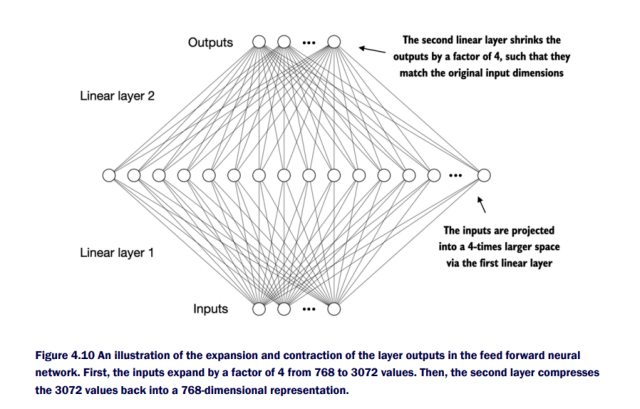

In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.10.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### the uniformity in input and output dimensions simplifies the architecture by enabling the stacking of multiple layers, as we will do later, without the need to adjust dimensions between them, thus making the model more scalabl

##### we have now implemented most of the LLM's building blocks.

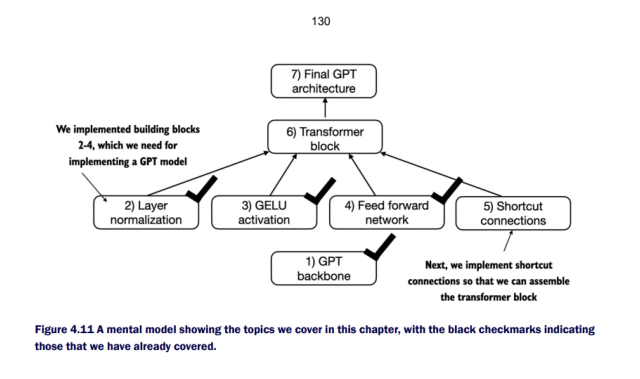

In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.11.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### we will go over the concept of shortcut connections that we insert between different layers of a neural network, which are important for improving the training performance in deep neural network architectures

### 4.4 Adding shortcut connections

##### Shortcut connections (also called skip connections or residual connections) are connections that let the input of a layer bypass one or more layers and get added back to the output.

##### , a shortcut connection creates an alternative, shorter path for the gradient to flow through the network by skipping one or more layers, which is achieved by adding the output of one layer to the output of a later layer. This is why these connections are also known as skip connections. They play a crucial role in preserving the flow of gradients during the backward pass in training.


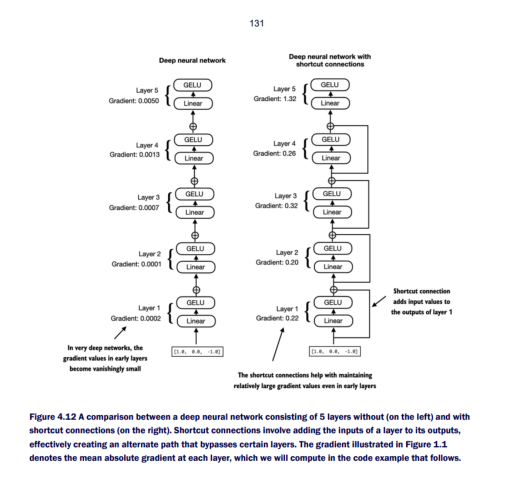

In [33]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.12.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### we implement the neural network shown in Figure 4.12 to see how we can add shortcut connections in the forward method:

In [34]:
import torch
import torch.nn as nn

class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()

        self.use_shortcut = use_shortcut

        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(layer_sizes[0], layer_sizes[1]),
                nn.GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[1], layer_sizes[2]),
                nn.GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[2], layer_sizes[3]),
                nn.GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[3], layer_sizes[4]),
                nn.GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[4], layer_sizes[5]),
                nn.GELU()
            )
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)

            # Apply shortcut connection if enabled and shapes match
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output

        return x

##### The code implements a deep neural network with 5 layers, each consisting of a Linear layer and a GELU activation function. In the forward pass, we iteratively pass the input through the layers and optionally add the shortcut connections depicted in Figure 4.12 if the self.use_shortcut attribute is set to True

In [35]:
layer_sizes=[3,3,3,3,3,1]
sample_input=torch.tensor([[1.,0.,-1.]])
torch.manual_seed(123)
model_without_shortcut=ExampleDeepNeuralNetwork(layer_sizes,use_shortcut=False)

##### Next, we implement a function that computes the gradients in the the model's backward pass:

In [36]:
import torch
import torch.nn as nn

def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.0]])
    loss_fn = nn.MSELoss()
    loss = loss_fn(output, target)
    # backward pass
    loss.backward()

    # Print the mean absolute gradient of each weight matrix
    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [37]:
print_gradients(model_without_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.00020174116070847958
layers.1.0.weight has gradient mean of 0.0001201176637550816
layers.2.0.weight has gradient mean of 0.0007152435719035566
layers.3.0.weight has gradient mean of 0.0013988512801006436
layers.4.0.weight has gradient mean of 0.005049605388194323


##### as we can see based on the output of the print_gradients function, the gradients become smaller as we progress from the last layer (layers.4) to the first layer (layers.0), which is a phenomenon called the vanishing gradient problem

##### Let's now instantiate a model with skip connections and see how it compares

In [38]:
torch.manual_seed(123)
model_with_shortcut=ExampleDeepNeuralNetwork(layer_sizes,use_shortcut=True)
print_gradients(model_with_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.22186796367168427
layers.1.0.weight has gradient mean of 0.20709273219108582
layers.2.0.weight has gradient mean of 0.32923877239227295
layers.3.0.weight has gradient mean of 0.2667772173881531
layers.4.0.weight has gradient mean of 1.3268063068389893


##### as we can see, based on the output, the last layer (layers.4) still has a larger gradient than the other layers

##### In conclusion, shortcut connections are important for overcoming the limitations posed by the vanishing gradient problem in deep neural networks. Shortcut connections are a core building block of very large models such as LLMs, and they will help facilitate more effective training by ensuring consistent gradient flow across layers when we train the GPT model later on

##### after introducing shortcut connections, we will now connect all of the previously coveredconcepts (layer normalization, GELU activations, feed forward module, and shortcutconnections) in a transformer block in the next section, which is the final building block we need to code the GPT architecture.

### 4.5 Connecting attention and linear layers in a transformer block

##### in this section, we implement the transformer block, a fundamental building block of GPT and other LLM architecture

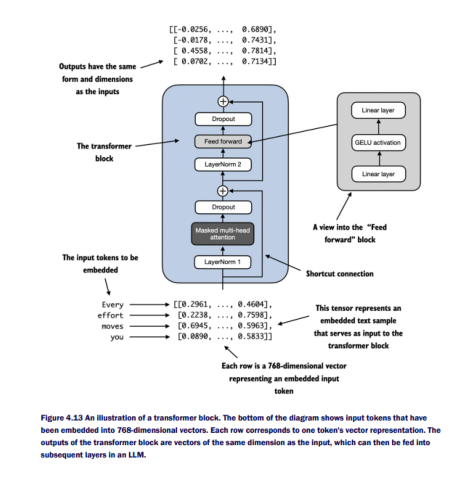

In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.13.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### when a transformer block processes an input sequence, each element in the sequence (for example, a word or subword token) is represented by a fixed-size vector (in the case of Figure 4.13, 768 dimensions). The operations within the transformer block, including multihead attention and feed forward layers, are designed to transform these vectors in a way that preserves their dimensionality.

### before implementing this part, please visit the component.py fild and usage.py file where all the components used here are written with usage example so that no confusion occur.

In [40]:
# NOTE:
# This implementation uses the GPT-2 Pre-LayerNorm architecture:
#     LayerNorm → Attention → Add
# instead of the original Transformer:
#     Attention → Add → LayerNorm, so use the transformer block follows the above transformer arch,not the attention is all u need paper.

In [41]:
from components import MaskedMultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.norm1=LayerNorm(cfg["emb_dim"])
        
        self.att=MaskedMultiHeadAttention(
            input_dim=cfg["emb_dim"],
            output_dim=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        
        self.norm2=LayerNorm(cfg["emb_dim"])
        
        self.ff=FeedForward(cfg)
        self.dropout_shortcut= nn.Dropout(cfg["drop_rate"])

    def forward(self,x):
        shortcut= x
        x= self.norm1(x)
        x=self.att(x)
        x=self.dropout_shortcut(x)
        x=x+shortcut

        shortcut=x
        x=self.norm2(x)
        x=self.ff(x)
        x=self.dropout_shortcut(x)
        x=x+shortcut
        return x

##### the given code defines a TransformerBlock class in PyTorch that includes a masked multi-head attention mechanism (MaskedMultiHeadAttention) and a feed forward network (FeedForward), both configured based on a provided configuration dictionary (cfg), such as GPT_CONFIG_124M

##### layer normalization (LayerNorm) is applied before each of these two components, and dropout is applied after them to regularize the model and prevent overfitting. This is also known as Pre-LayerNorm. Older architectures, such as the original transformer model,applied layer normalization after the self-attention and feed-forward networks instead, known as Post-LayerNorm, which often leads to worse training dynamics.  The class also implements the forward pass, where each component is followed by a shortcut connection that adds the input of the block to its output. This critical feature helps gradients flow through the network during training and improves the learning of deep models 

##### Using the GPT_CONFIG_124M dictionary we defined earlier, instantiate a transformer block and feed it some sample data:

In [42]:
torch.manual_seed(123)
x=torch.rand(2,4,768)
block=TransformerBlock(GPT_CONFIG_124M)
output=block(x)

In [43]:
print("input shape",x.shape)
print("output shape",output.shape)

input shape torch.Size([2, 4, 768])
output shape torch.Size([2, 4, 768])


##### as we can see from the code output, the transformer block maintains the input dimensions in its output, indicating that the transformer architecture processes sequences of data without altering their shape throughout the network.


##### sequence with the transformer block implemented in this section, we now have all the building blocks, as shown in Figure 4.14 below, needed to implement the GPT architecture in the nextsection.

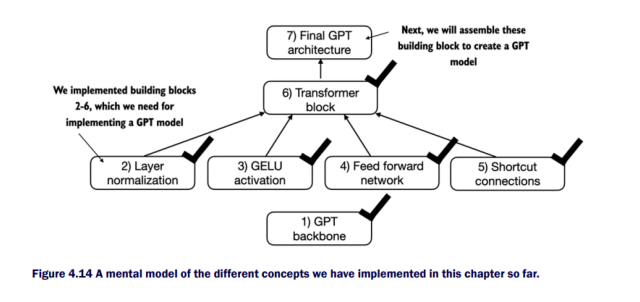

In [44]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.14.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

### 4.6 - Coding the GPT model

In [45]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        # output projection
        self.out_head = nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)

        return logits

#####  initialize the 124 million parameter GPT model using the GPT_CONFIG_124M

In [46]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
out=model(batch)
print("input batch \n",batch)
print("input batch shape \n",batch.shape)
print("output shape \n",out.shape)
print(out)

input batch 
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
input batch shape 
 torch.Size([2, 4])
output shape 
 torch.Size([2, 4, 50257])
tensor([[[-0.4872,  0.3348, -0.1772,  ..., -0.1368,  0.3863, -0.8503],
         [-0.5416, -0.2878, -0.2150,  ..., -0.4021, -0.0299, -0.7093],
         [-0.1084,  0.3266,  0.4185,  ..., -0.5073, -0.1000, -0.6559],
         [-1.3887,  0.4579,  0.0882,  ..., -0.1296,  0.1117, -0.3099]],

        [[-0.8121, -0.0275,  0.2129,  ..., -0.3532,  0.4499, -1.0668],
         [-0.4674,  0.5922, -0.0210,  ..., -0.2368, -0.2147, -0.4215],
         [ 0.1825,  0.8852, -0.0424,  ...,  0.0504,  0.1551, -0.4213],
         [-0.6865,  0.2704,  0.0080,  ...,  0.1832, -0.2221, -0.4373]]],
       grad_fn=<UnsafeViewBackward0>)


##### before we move on to the next section and code the function that converts the model outputs into text, let's spend a bit more time with the model architecture itself and analyze its size.


In [47]:
total_params=sum(p.numel() for p in model.parameters())
print(f"total number of paramters: {total_params:,}")

total number of paramters: 163,009,536


######  we spoke of initializing a 124 million parameter GPT model, so why is the actual number of parameters 163 million, as shown in the preceding code output?

###### the reason is a concept called weight tying that is used in the original GPT-2 architecture, which means that the original GPT-2 architecture is reusing the weights from the token embedding layer in its output layer. To understand what this means, let's take a look at the shapes of the token embedding layer and linear output layer that we initialized on the model via the GPTModel earlier:


In [48]:
print("token emb layer shape",model.tok_emb.weight.shape)

token emb layer shape torch.Size([50257, 768])


In [49]:
print("output layer shape",model.out_head.weight.shape)

output layer shape torch.Size([50257, 768])


#####  the token embedding and output layers are very large due to the number of rows for the 50,257 in the tokenizer's vocabulary. Let's remove the output layer parameter count from the total GPT-2 model count according to the weight tying:


In [50]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


##### As we can see, the model is now only 124 million parameters large, matching the original size of the GPT-2 model. Weight tying reduces the overall memory footprint and computational complexity of the model. However, in my experience, using separate token embedding and output layers results in better training and model performance; hence, we are using separate layers in our GPTModel implementation. The same is true for modern LLMs. However, we will revisit and implement the weight tying concept later in chapter 6 when we load the pretrained weights from OpenAI.


##### lastly, let us compute the memory requirements of the 163 million parameters in ourGPTModel object:

In [51]:
total_size_bytes = total_params * 4 
total_size_mb = total_size_bytes / (1024 * 1024) 
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


##### In this section, we implemented the GPTModel architecture and saw that it outputs numeric tensors of shape [batch_size, num_tokens, vocab_size]. In the next section, we will write the code to convert these output tensors into tex

### 4.7 Generating text

##### In this final section of this chapter, we will implement the code that converts the tensor outputs of the GPT model back into text. Before we get started, let's briefly review how a generative model like an LLM generates text one word (or token) at a time, as shown in Figure 4.16

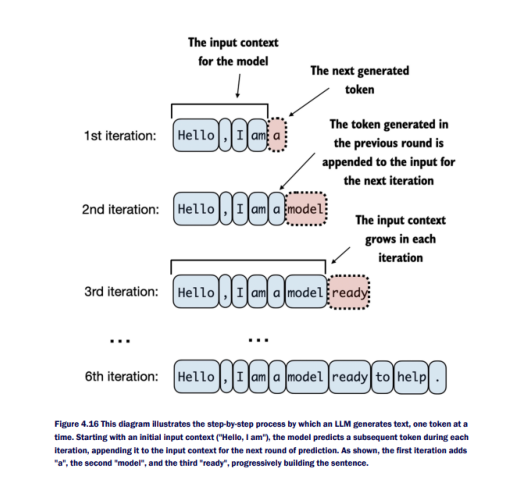

In [52]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.16.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### the process by which a GPT model goes from output tensors to generated text involves several steps, as illustrated in Figure 4.17. These steps include decoding the output tensors, selecting tokens based on a probability distribution, and converting these tokens into human-readable tex

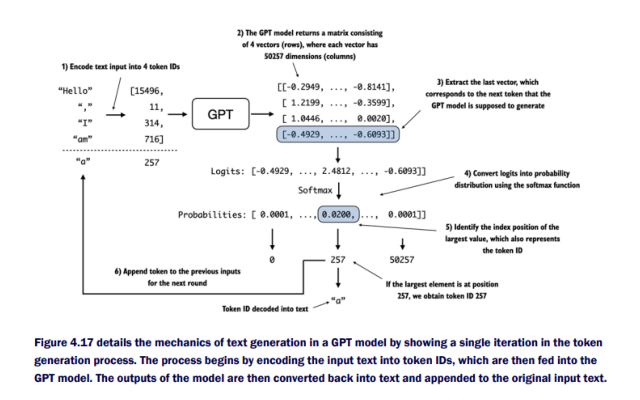

In [53]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.17.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### listing 4.8 A function for the GPT model to generate text

In [54]:
import torch


def generate_text_simple(model, input_tokens, max_new_tokens, context_size):
    """
    generate text one token at a time.

    Parameters
    ----------
    model : GPTModel
        The trained GPT model.

    input_tokens : torch.Tensor
        Initial prompt as token IDs.
        Shape: (batch_size, sequence_length)

    max_new_tokens : int
        Number of new tokens to generate.

    context_size : int
        Maximum number of previous tokens the model can attend to.
    """

    # start with the initial prompt
    generated_tokens = input_tokens
    # generate one token per iteration
    for step in range(max_new_tokens):
        print(f"\n========== Step {step + 1} ==========\n")
        # ---------------------------------------------------------
        # determine the current sequence length
        # ---------------------------------------------------------
        sequence_length = generated_tokens.shape[1]
        print(f"Current sequence length: {sequence_length}")
        # ---------------------------------------------------------
        # keep only the last context_size tokens
        #
        # if the sequence is shorter than the context size,
        # python slicing automatically returns the whole sequence.
        # ---------------------------------------------------------
        model_input = generated_tokens[:, -context_size:]
        print("\nInput sent to the model:")
        print(model_input)
        print("Shape:", model_input.shape)
        # ---------------------------------------------------------
        # run a forward pass through the model
        # no gradients are needed during inference
        # ---------------------------------------------------------
        with torch.no_grad():
            output_logits = model(model_input)
        print("\nModel output shape:")
        print(output_logits.shape)

        # output shape:
        # (batch_size, sequence_length, vocab_size)

        # ---------------------------------------------------------
        # take the logits corresponding to ONLY the last token
        #
        # every input token predicts the next token,
        # but we only care about the prediction for the
        # newest position.
        # ---------------------------------------------------------
        last_position_logits = output_logits[:, -1, :]
        print("\nLast position logits:")
        print(last_position_logits.shape)
        # shape:
        # (batch_size, vocab_size)

        # ---------------------------------------------------------
        # convert logits into probabilities
        # ---------------------------------------------------------
        probabilities = torch.softmax(
            last_position_logits,
            dim=-1
        )
        print("\nProbability vector:")
        print(probabilities.shape)
        # ---------------------------------------------------------
        # choose the token with the highest probability
        #
        # argmax returns the index of the largest value,
        # which corresponds to the predicted token ID.
        # ---------------------------------------------------------
        predicted_token = torch.argmax(
            probabilities,
            dim=-1,
            keepdim=True
        )
        print("\nPredicted token ID:")
        print(predicted_token)
        # shape:
        # (batch_size, 1)

        # ---------------------------------------------------------
        # append the predicted token to the current sequence
        #
        # before:
        # [10, 20, 30]
        #
        # predicted:
        # [40]
        #
        # after:
        # [10, 20, 30, 40]
        # ---------------------------------------------------------
        generated_tokens = torch.cat(
            (generated_tokens, predicted_token),
            dim=1
        )
        print("\nSequence after appending:")
        print(generated_tokens)
        print("New shape:", generated_tokens.shape)

    # ---------------------------------------------------------
    # after generating all requested tokens,
    # return the complete sequence
    # ---------------------------------------------------------
    return generated_tokens

In [55]:
start_context = "Hello, I am"
encoded=tokenizer.encode(start_context)
print("encoded:",encoded)
encoded_tensor= torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor shape: torch.Size([1, 4])


##### next, we put the model into .eval() mode, which disables random components like dropout, which are only used during training, and use the generate_text_simple function  on the encoded input tensor

In [56]:
model.eval()
out=generate_text_simple(
    model=model,
    input_tokens=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:",out)
print("Output length:",len(out[0]))


========== Step 1 ==========

Current sequence length: 4

Input sent to the model:
tensor([[15496,    11,   314,   716]])
Shape: torch.Size([1, 4])

Model output shape:
torch.Size([1, 4, 50257])

Last position logits:
torch.Size([1, 50257])

Probability vector:
torch.Size([1, 50257])

Predicted token ID:
tensor([[27018]])

Sequence after appending:
tensor([[15496,    11,   314,   716, 27018]])
New shape: torch.Size([1, 5])

========== Step 2 ==========

Current sequence length: 5

Input sent to the model:
tensor([[15496,    11,   314,   716, 27018]])
Shape: torch.Size([1, 5])

Model output shape:
torch.Size([1, 5, 50257])

Last position logits:
torch.Size([1, 50257])

Probability vector:
torch.Size([1, 50257])

Predicted token ID:
tensor([[14838]])

Sequence after appending:
tensor([[15496,    11,   314,   716, 27018, 14838]])
New shape: torch.Size([1, 6])

========== Step 3 ==========

Current sequence length: 6

Input sent to the model:
tensor([[15496,    11,   314,   716, 27018, 14

##### using the .decode method of the tokenizer, we can convert the IDs back into text:

In [57]:
decoded_text=tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Feature unlocked killed452 unlocked unlocked


##### As we can see, based on the preceding output, the model generated gibberish, which is not at all like the coherent text shown in Figure 4.18. What happened? The reason why the model is unable to produce coherent text is that we haven't trained it y et. So far, we justimplemented the GPT architecture and initialized a GPT model instance with initial random weights.


##### model training is a large topic in itself, and we will tackle it in the next chapter.

# Chapter Summary

- **Layer Normalization**
  - Stabilizes training by ensuring each layer's outputs have a consistent **mean** and **variance**.
  - Helps improve training stability and convergence.

- **Shortcut (Residual) Connections**
  - Skip one or more layers by passing the output of one layer directly to a deeper layer.
  - Help mitigate the **vanishing gradient problem**, making it possible to train deep neural networks like LLMs.

- **Transformer Blocks**
  - The fundamental building blocks of GPT models.
  - Each transformer block consists of:
    - **Masked Multi-Head Self-Attention**
    - **Feed-Forward Neural Network (FFN)** using the **GELU** activation function
    - **Layer Normalization**
    - **Residual (Shortcut) Connections**

- **GPT Model Architecture**
  - Built by stacking many transformer blocks together.
  - Contains **millions to billions of trainable parameters**.
  - Uses the same overall architecture regardless of model size.

- **GPT Model Sizes**
  - The same `GPTModel` implementation can represent different GPT variants by changing the configuration.
  - Common GPT-2 model sizes include:
    - **124M parameters**
    - **355M parameters**
    - **774M parameters**
    - **1.5B (1542M) parameters**

- **Text Generation**
  - Generates text **one token at a time**.
  - Process:
    1. Feed the current sequence into the model.
    2. Predict the next token.
    3. Append the predicted token to the sequence.
    4. Repeat until the desired number of tokens is generated.
  - The generated token IDs are then decoded back into human-readable text.

- **Importance of Training**
  - An untrained GPT model produces **random and incoherent text**.
  - Training enables the model to learn language patterns, grammar, context, and reasoning, allowing it to generate meaningful and coherent text.
  - The next chapters focus on training the GPT model.